# Bet Timeline — Individual bets & net money flow per market
**Two charts per market across all 20 political bets:**
1. Every individual bet placed over time (size vs time, BUY/SELL coloured)
2. Cumulative net money flow (BUY − SELL) over time

Price history (daily candles) is overlaid as a blue line so the complete market duration is always visible.

> The Data API exposes the most-recent ~3,000 fills per market. For low-volume markets these span the full lifetime; for high-volume markets they compress near resolution.

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import httpx
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10,
                     'axes.labelsize': 9, 'xtick.labelsize': 7,
                     'ytick.labelsize': 7, 'legend.fontsize': 7})

EDA     = Path('.')
C_BUY   = '#2ea043'
C_SELL  = '#cf222e'
C_PRICE = '#0075ca'
C_NET   = '#6e40c9'

fmt_usdc = mticker.FuncFormatter(
    lambda v, _: f'${abs(v)/1e6:.1f}M' if abs(v) >= 1e6
    else f'${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'${abs(v):.0f}'
)

In [2]:
PRICE_SCHEMA = {'timestamp': pl.Int64, 'price': pl.Float64}
markets = pl.read_csv(EDA / 'markets.csv')

def load_ph(slug: str) -> pl.DataFrame:
    p = EDA / slug / 'price_history.csv'
    if not p.exists():
        return pl.DataFrame()
    return (
        pl.read_csv(p, schema_overrides=PRICE_SCHEMA)
        .with_columns((pl.col('timestamp') * 1_000_000)
                       .cast(pl.Datetime('us')).alias('date'))
    )

def fetch_all_trades(condition_id: str) -> pl.DataFrame:
    """Fetch up to ~3,000 most-recent fills for a market (API hard cap)."""
    rows, seen = [], set()
    with httpx.Client(base_url='https://data-api.polymarket.com', timeout=30) as client:
        for offset in range(0, 3000, 500):
            try:
                data = client.get('/trades',
                    params={'market': condition_id, 'limit': 500, 'offset': offset}
                ).json()
                if not isinstance(data, list) or not data:
                    break
                for r in data:
                    h = r.get('transactionHash', str(r.get('timestamp','')))
                    if h not in seen:
                        seen.add(h)
                        rows.append(r)
                if len(data) < 500:
                    break
            except Exception:
                break
    if not rows:
        return pl.DataFrame()
    df = pl.DataFrame({
        'timestamp': [int(r.get('timestamp', 0))   for r in rows],
        'price':     [float(r.get('price', 0))     for r in rows],
        'size':      [float(r.get('size', 0))      for r in rows],
        'side':      [str(r.get('side', ''))       for r in rows],
        'outcome':   [str(r.get('outcome', ''))    for r in rows],
    }).sort('timestamp')
    return df.with_columns(
        (pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date')
    )

print(f'{len(markets)} markets ready')

20 markets ready


## Per-market analysis
Runs top-to-bottom in descending volume order. Each market fetches live trade data (~3 seconds).  
**Panel 1** — every fill: size (log-scale) vs time, BUY=green SELL=red, blue line = daily price.  
**Panel 2** — net money: cumulative BUY and SELL USDC, purple line = net (BUY − SELL).

Fetching: Will Donald Trump win the 2024 US Presidential Election?


  3000 fills  span=0.1d  BUY=60%  net=$+5,261K


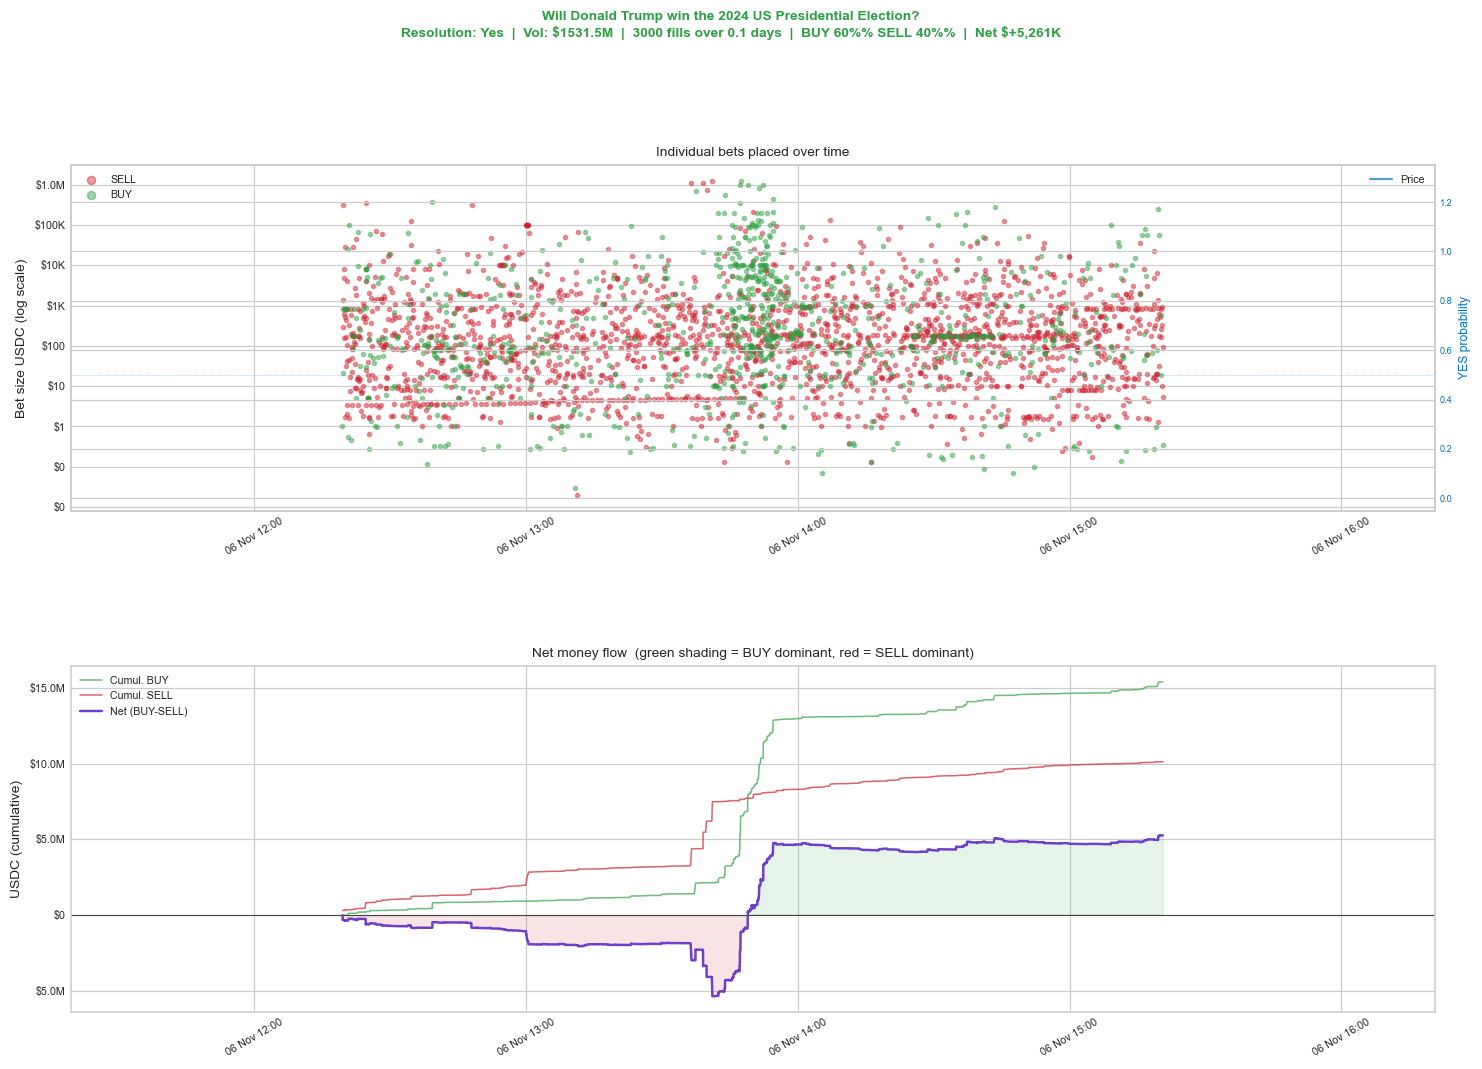


Fetching: Will Kamala Harris win the 2024 US Presidential Election?


  3000 fills  span=0.5d  BUY=46%  net=$-2,900K


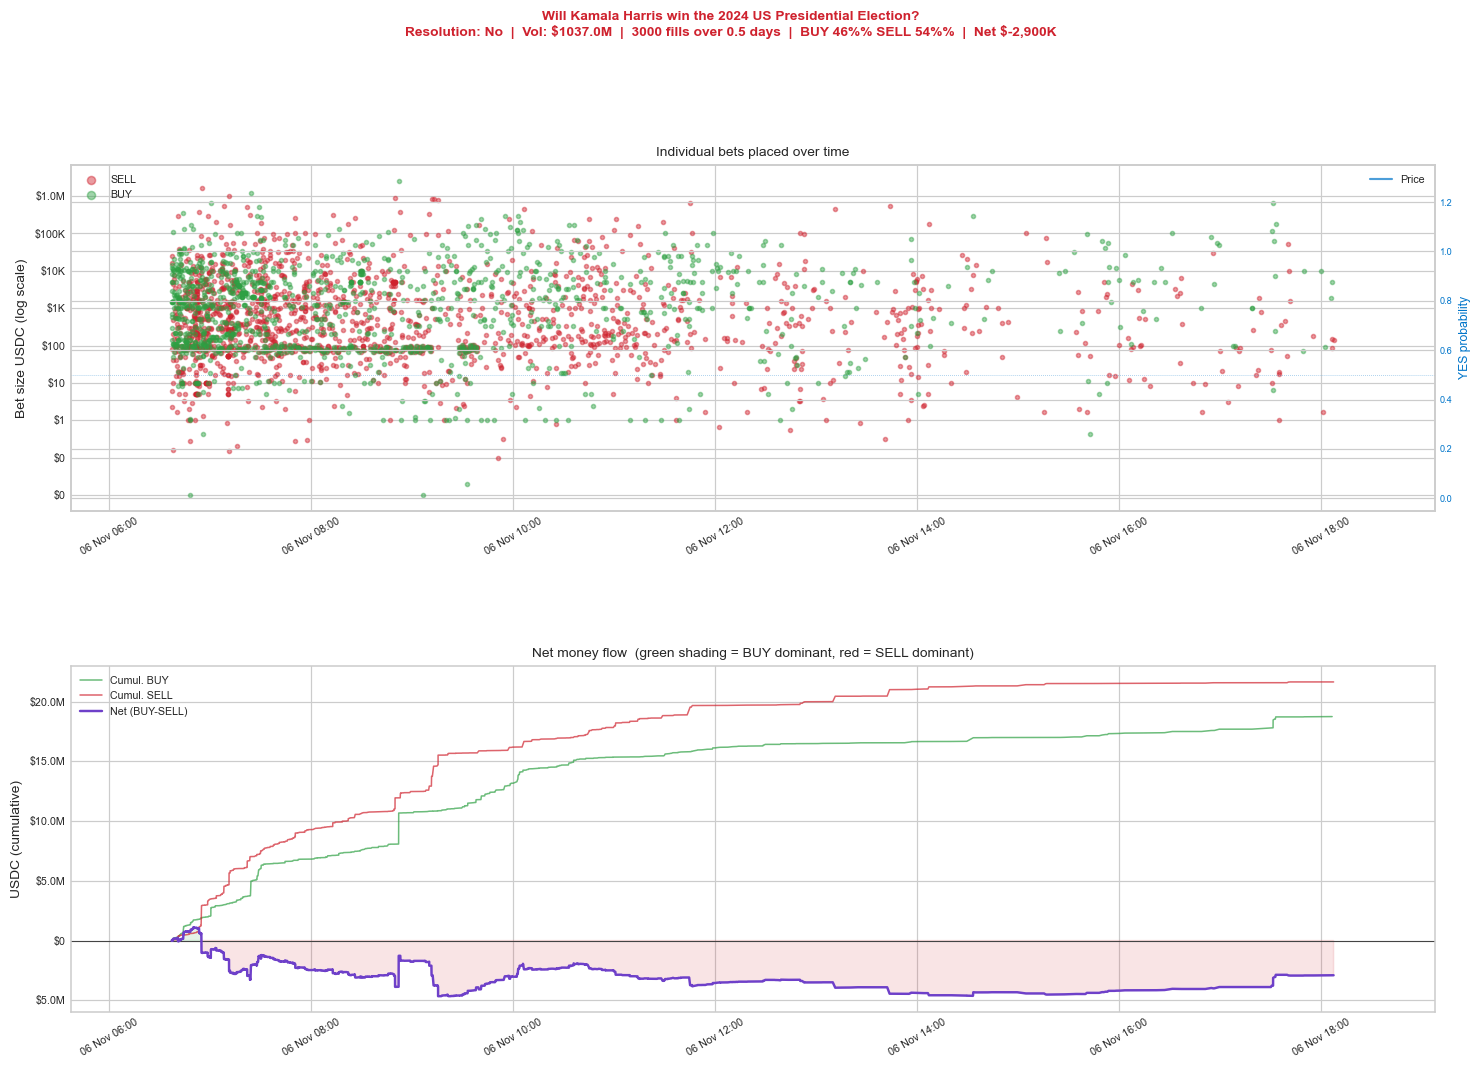


Fetching: Will Donald Trump be inaugurated?


  3000 fills  span=0.6d  BUY=40%  net=$-913K


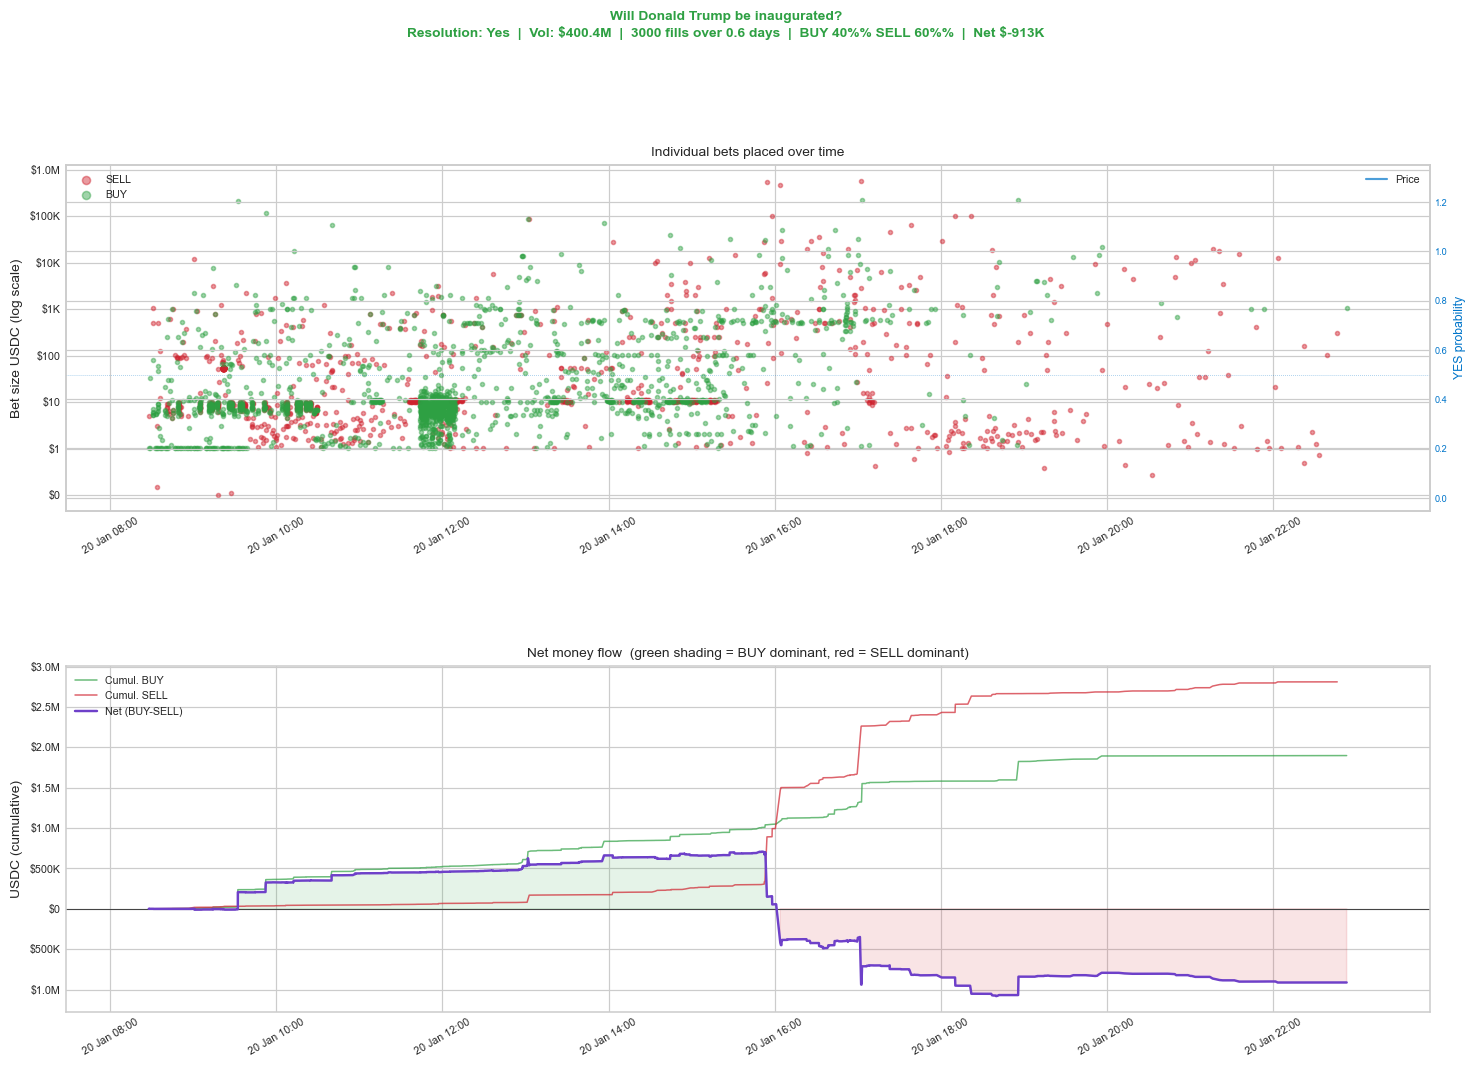


Fetching: Will Nicolae Ciucă win the 2024 Romanian Presidential election?


  3000 fills  span=9.5d  BUY=100%  net=$+67,240K


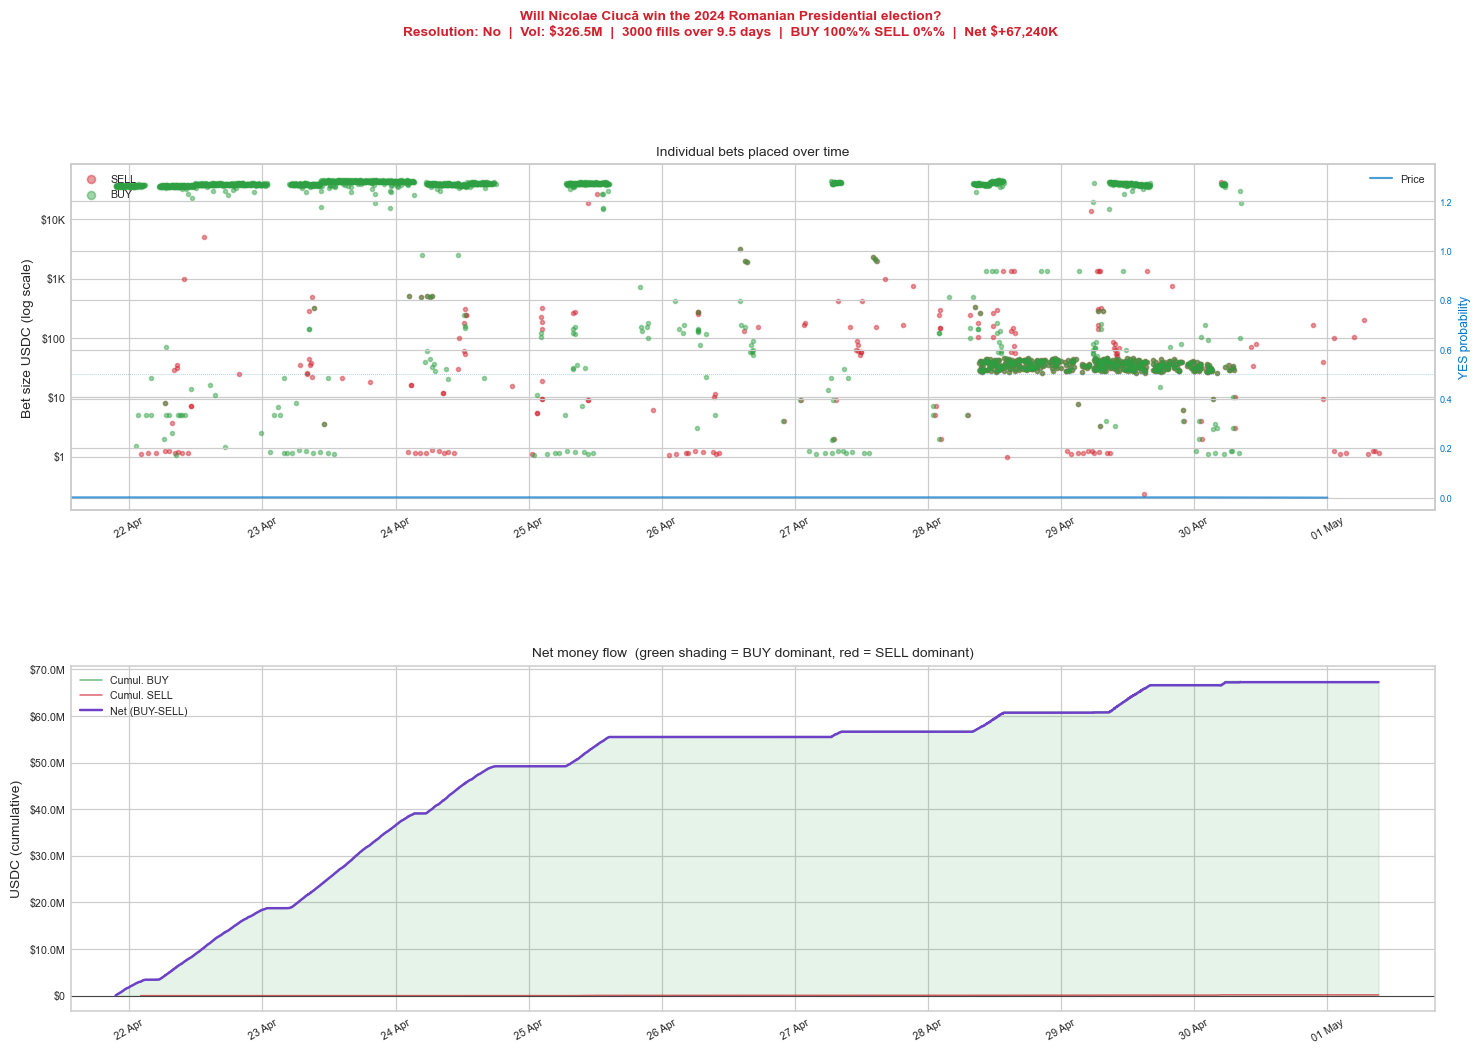


Fetching: Will any other Republican Politician win the 2024 US Presidential


  3000 fills  span=14.3d  BUY=88%  net=$+18,629K


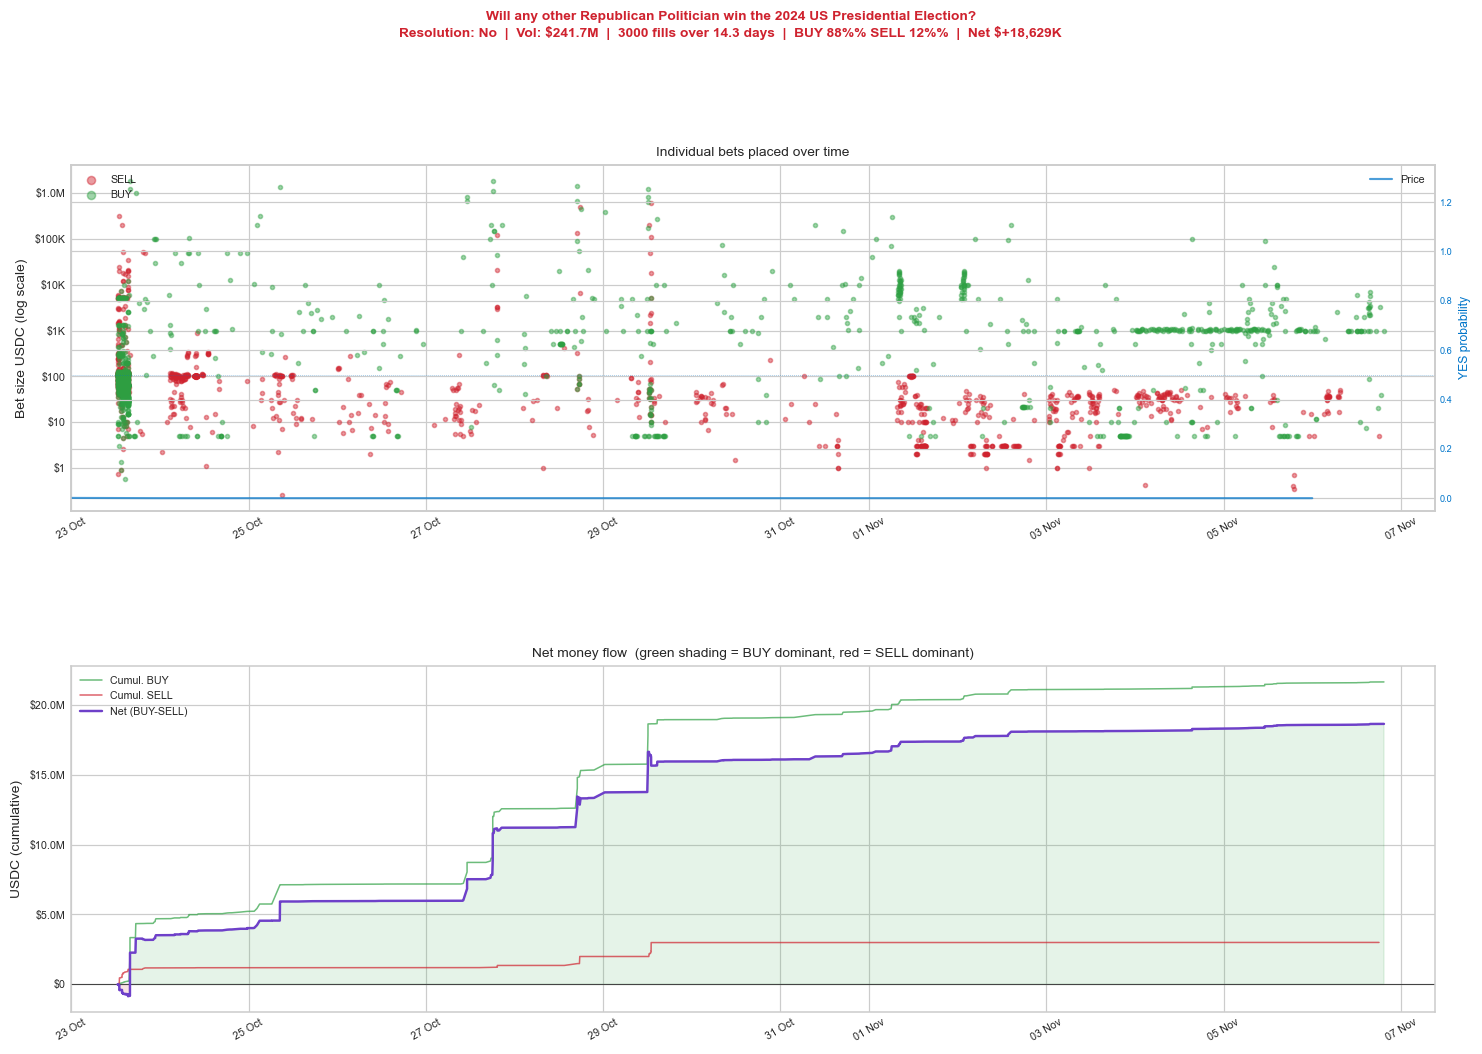


Fetching: Will Michelle Obama win the 2024 US Presidential Election?


  3000 fills  span=23.9d  BUY=84%  net=$+14,118K


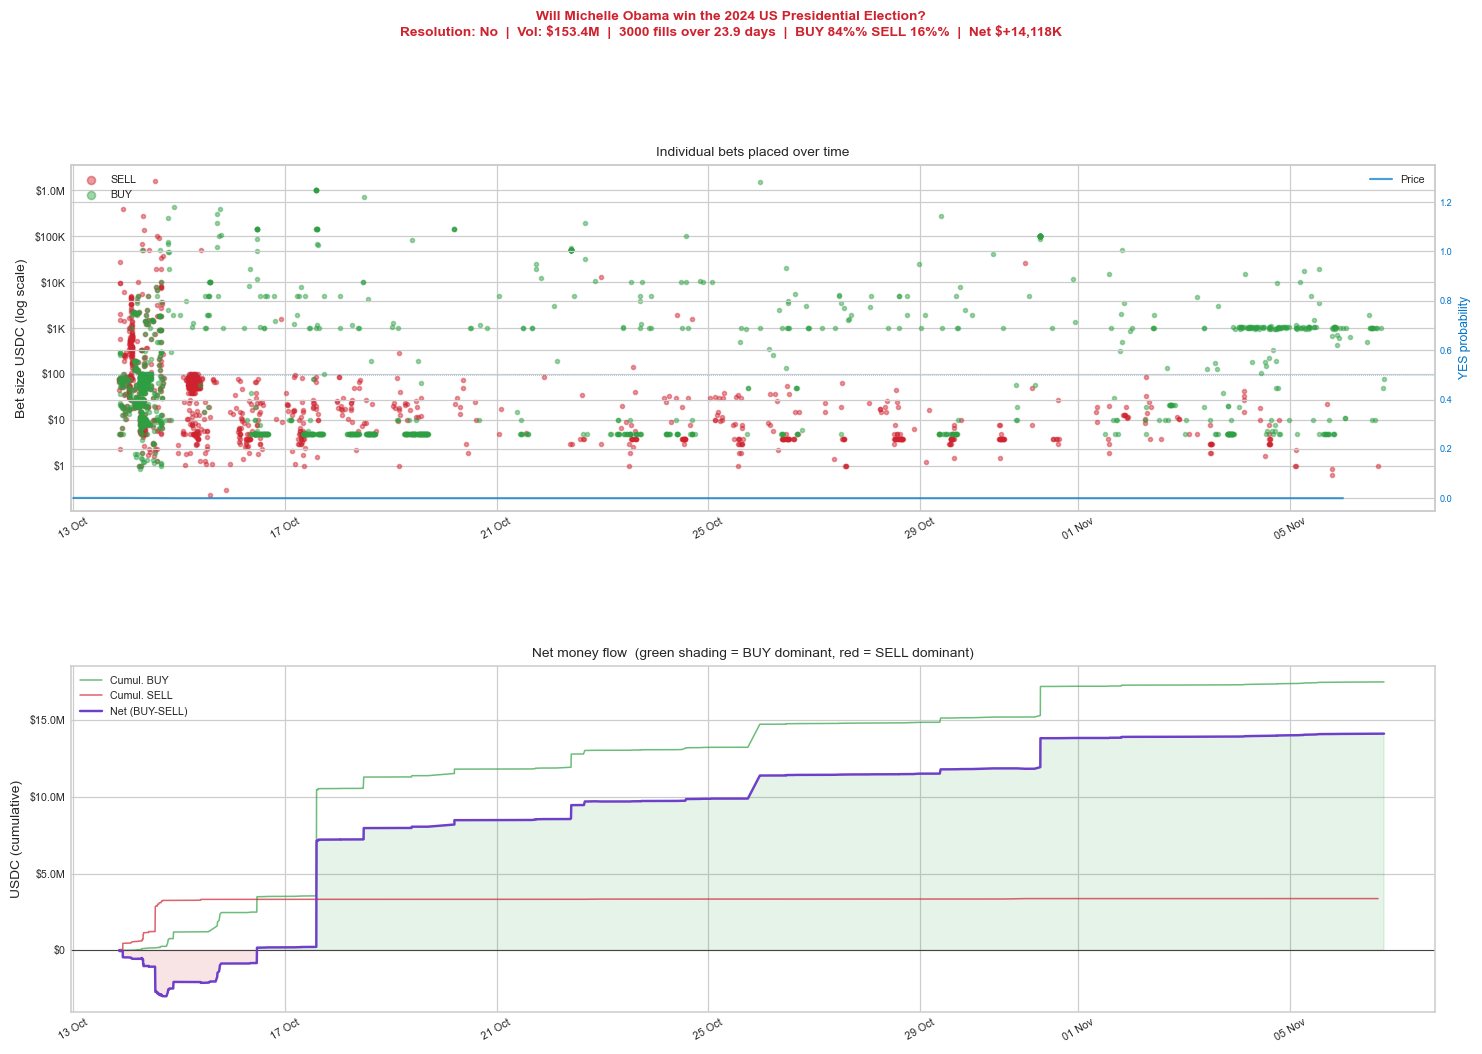


Fetching: Will Zohran Mamdani win the 2025 NYC mayoral election?


  3000 fills  span=0.2d  BUY=68%  net=$+5,338K


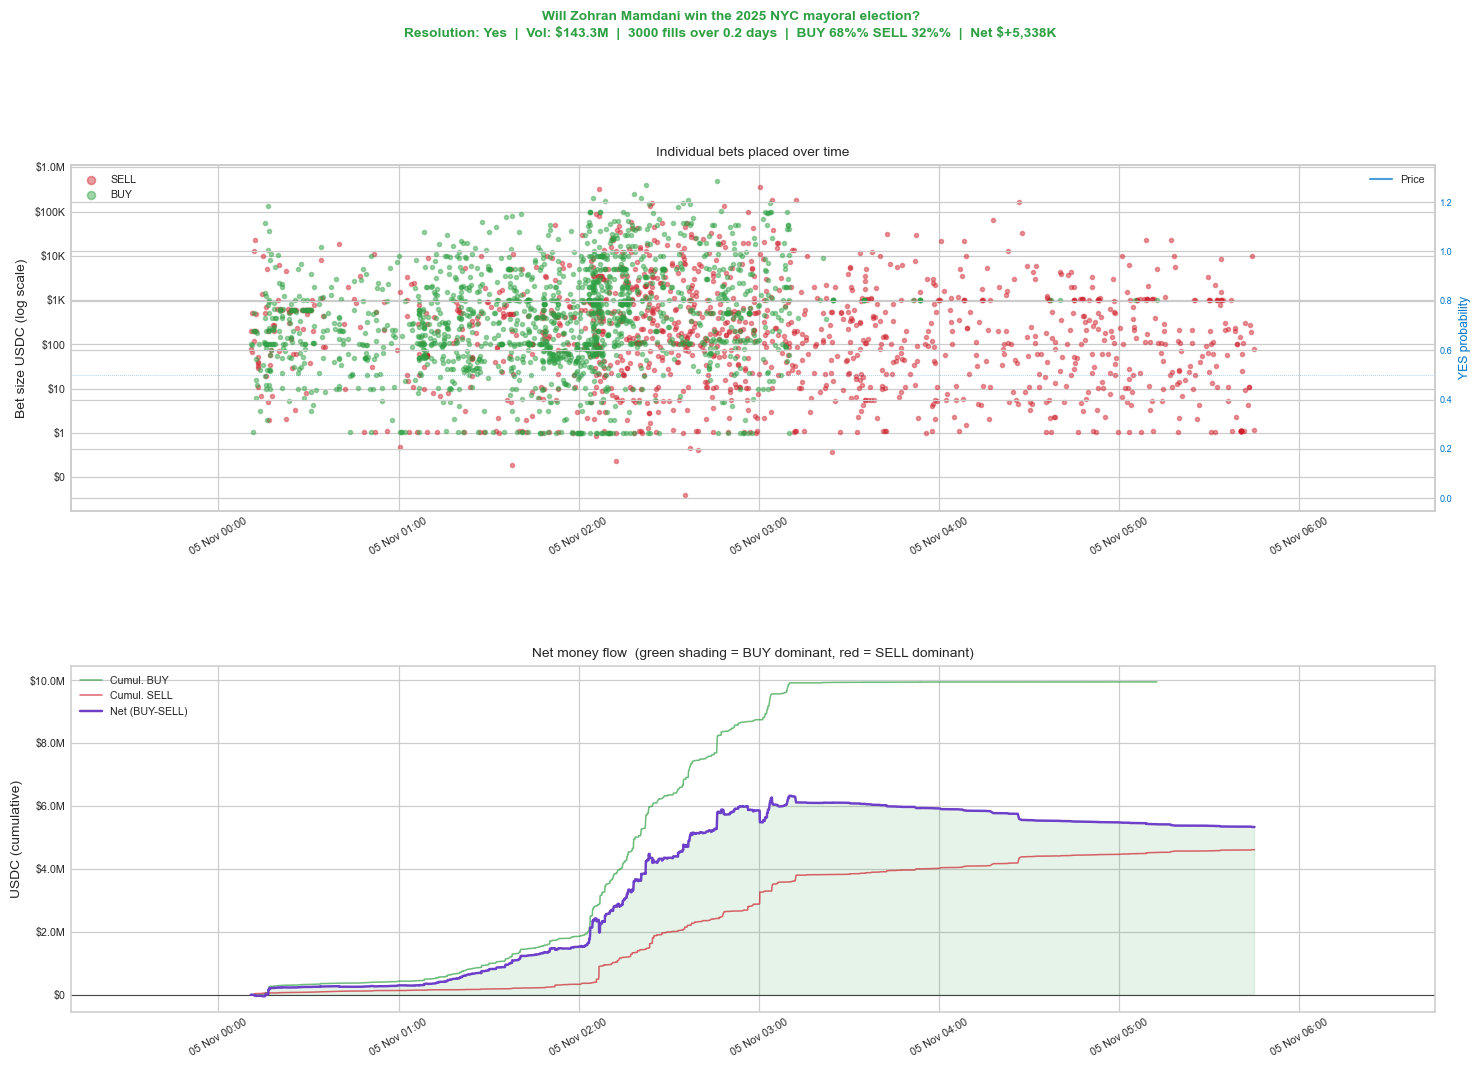


Fetching: Will Robert F. Kennedy Jr. win the 2024 US Presidential Election?


  3000 fills  span=23.0d  BUY=48%  net=$-242K


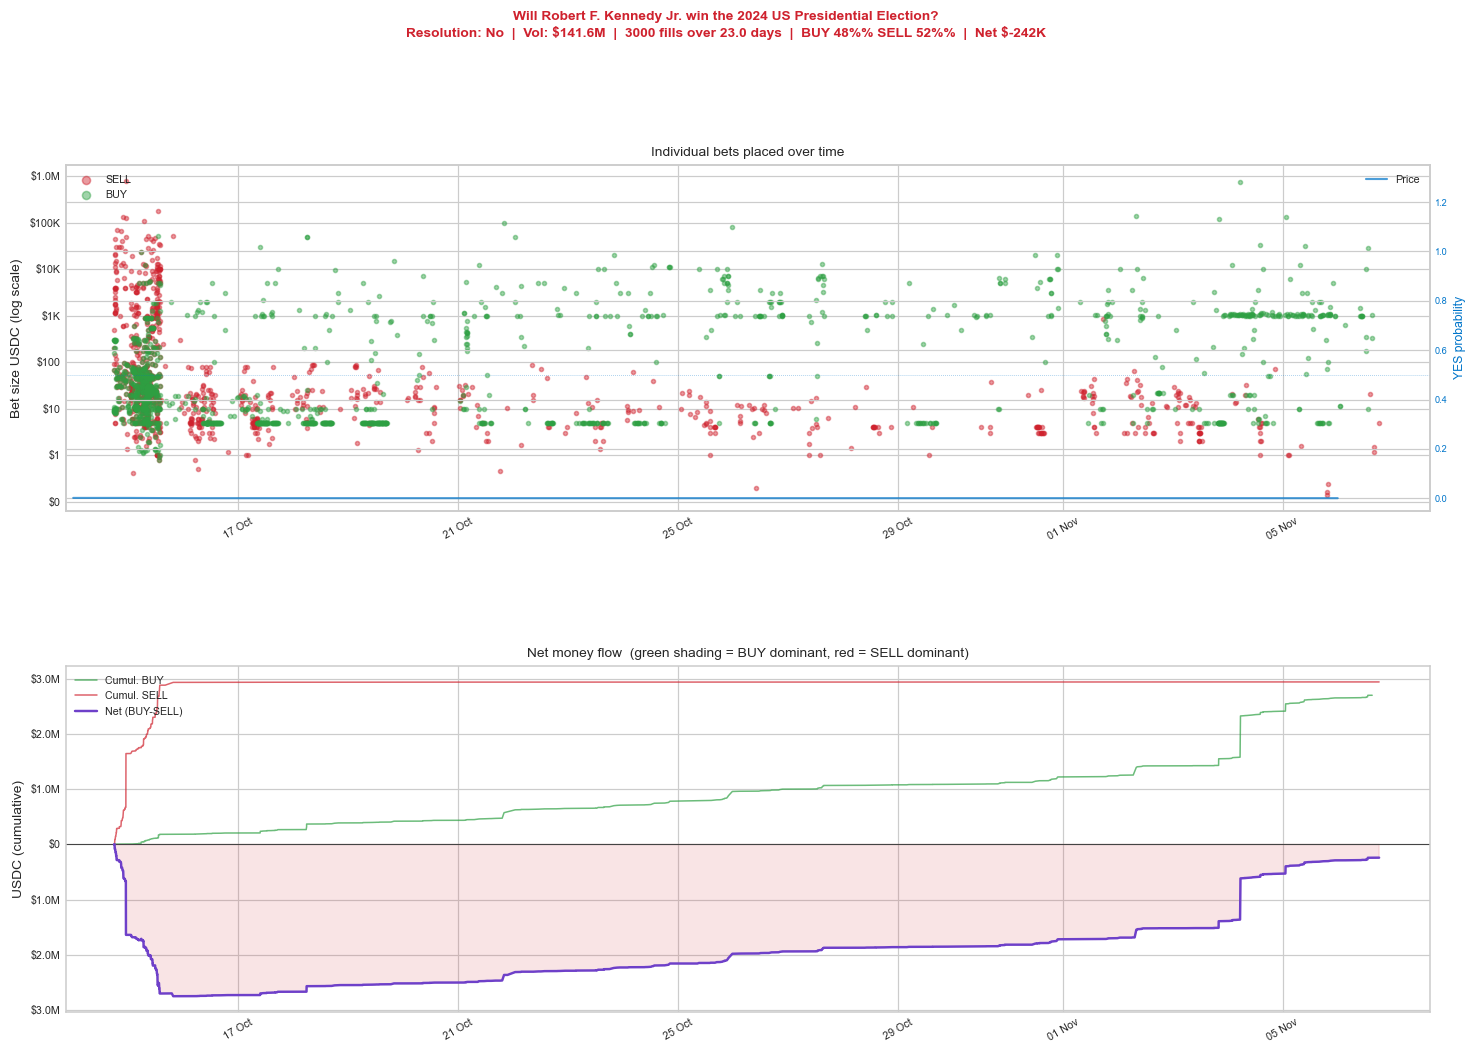


Fetching: Will Trump nominate Judy Shelton as the next Fed chair?


  3000 fills  span=0.6d  BUY=85%  net=$+16,153K


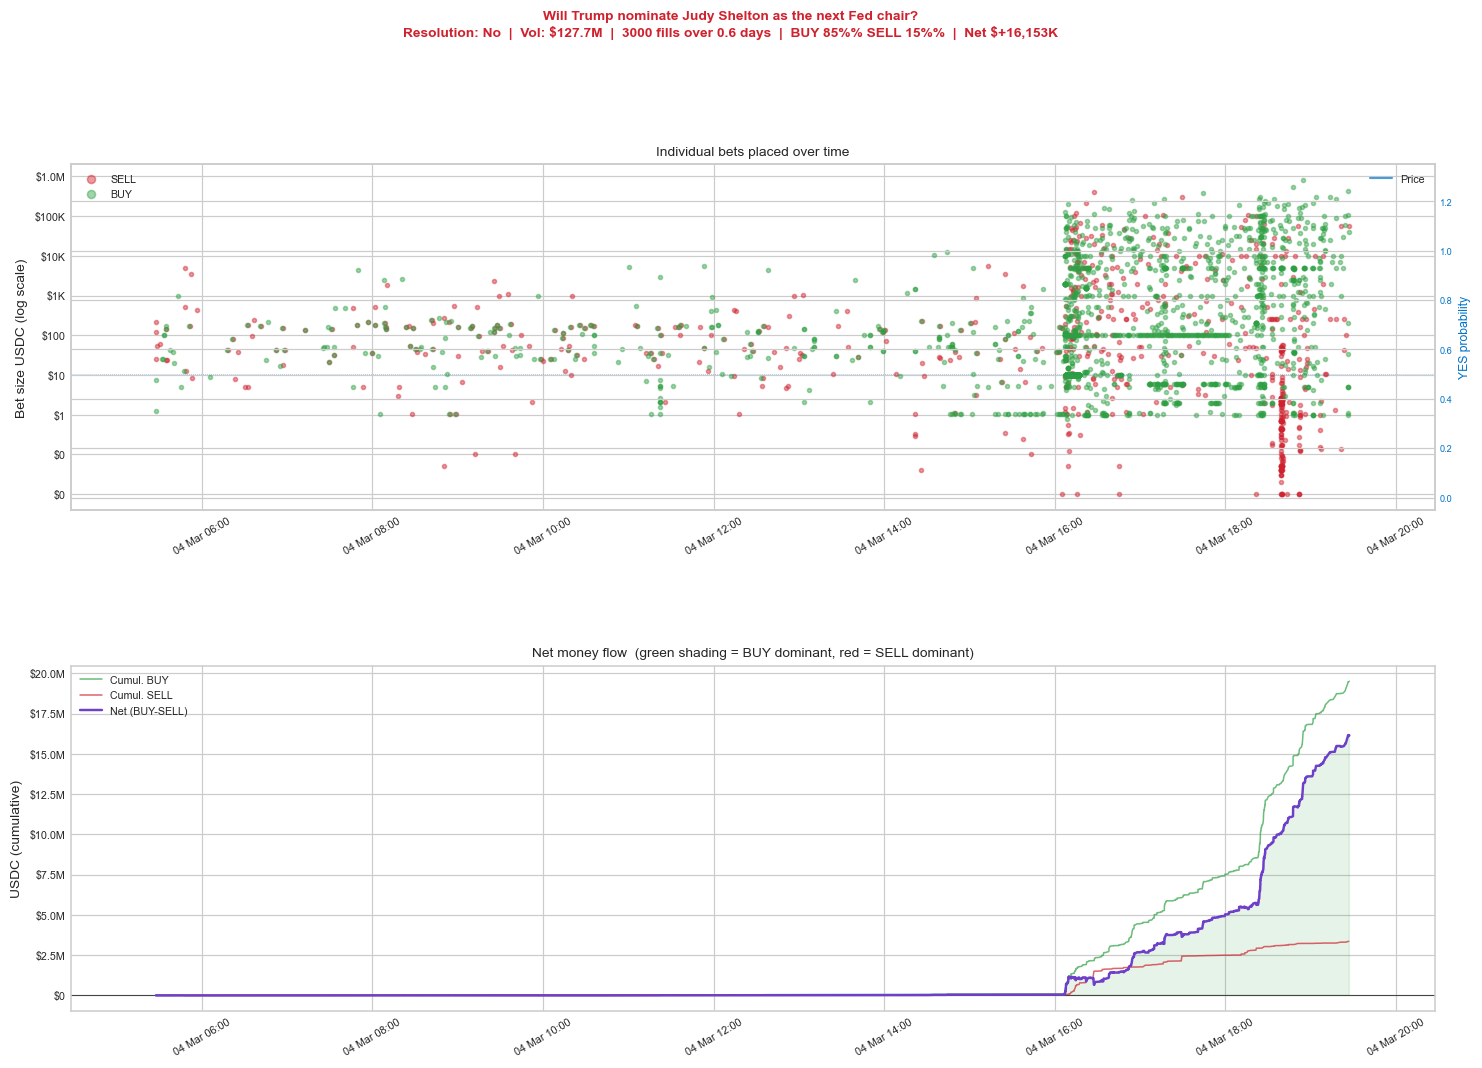


Fetching: Will any other Democratic Politician win the 2024 US Presidential


  3000 fills  span=23.3d  BUY=46%  net=$-942K


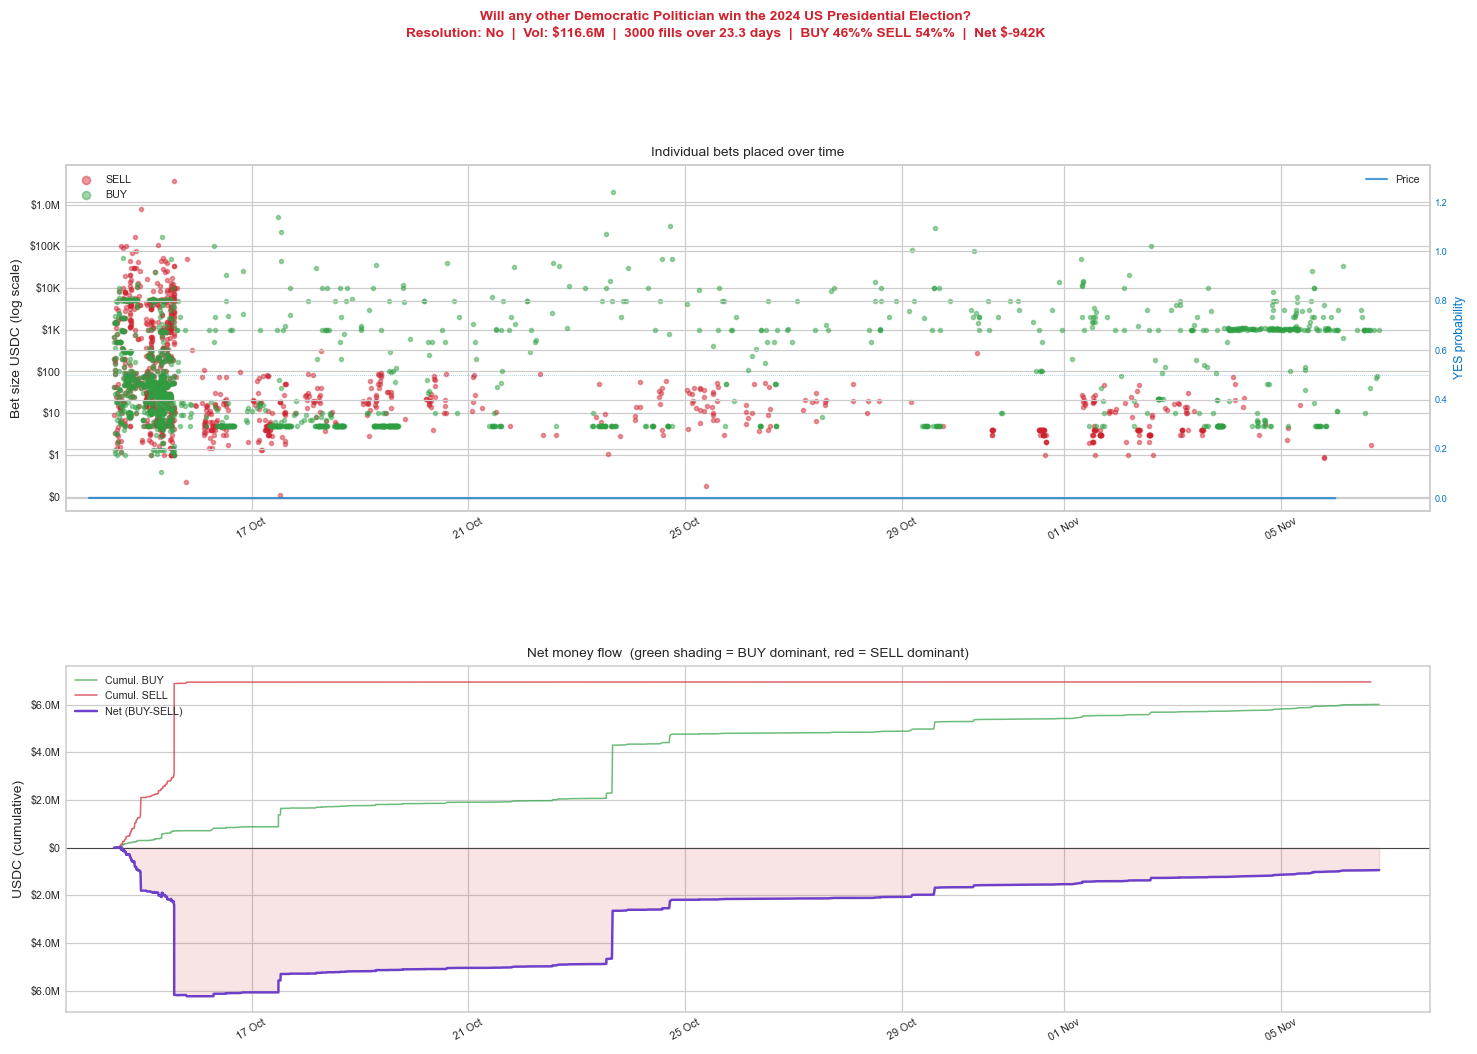


Fetching: Will Frances Fitzgerald win the Irish Presidential Election?


  3000 fills  span=181.7d  BUY=100%  net=$+114,341K


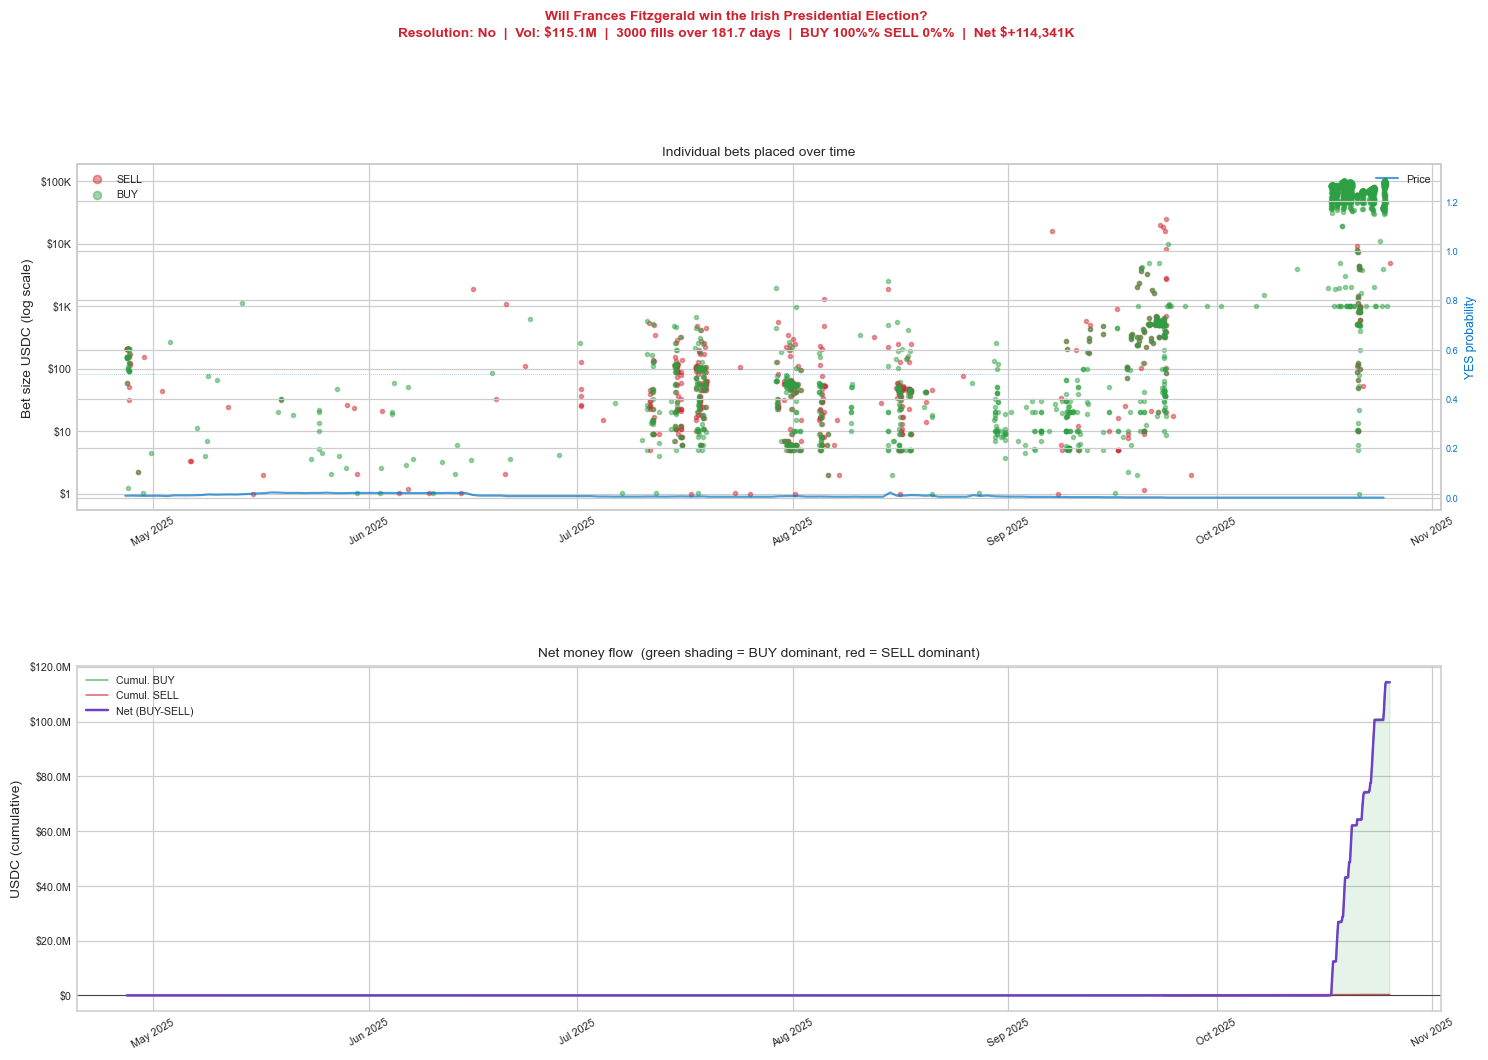


Fetching: Will Nikki Haley win the 2024 US Presidential Election?


  3000 fills  span=27.4d  BUY=39%  net=$-1,461K


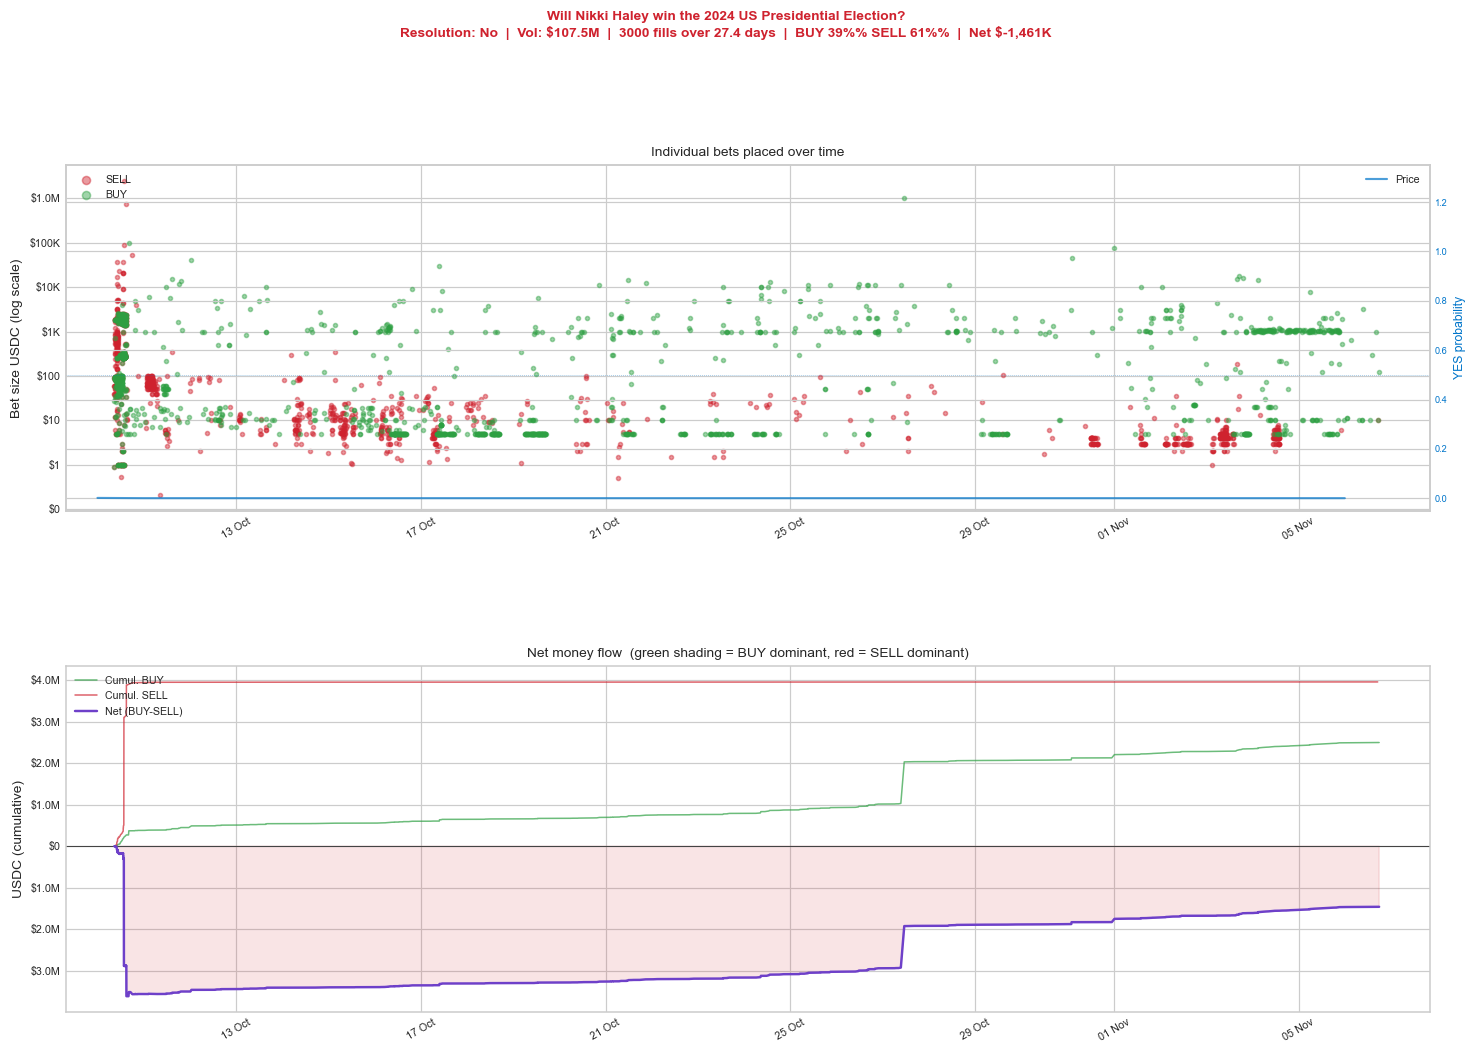


Fetching: Will Hillary Clinton win the 2024 US Presidential Election?


  3000 fills  span=29.5d  BUY=53%  net=$+777K


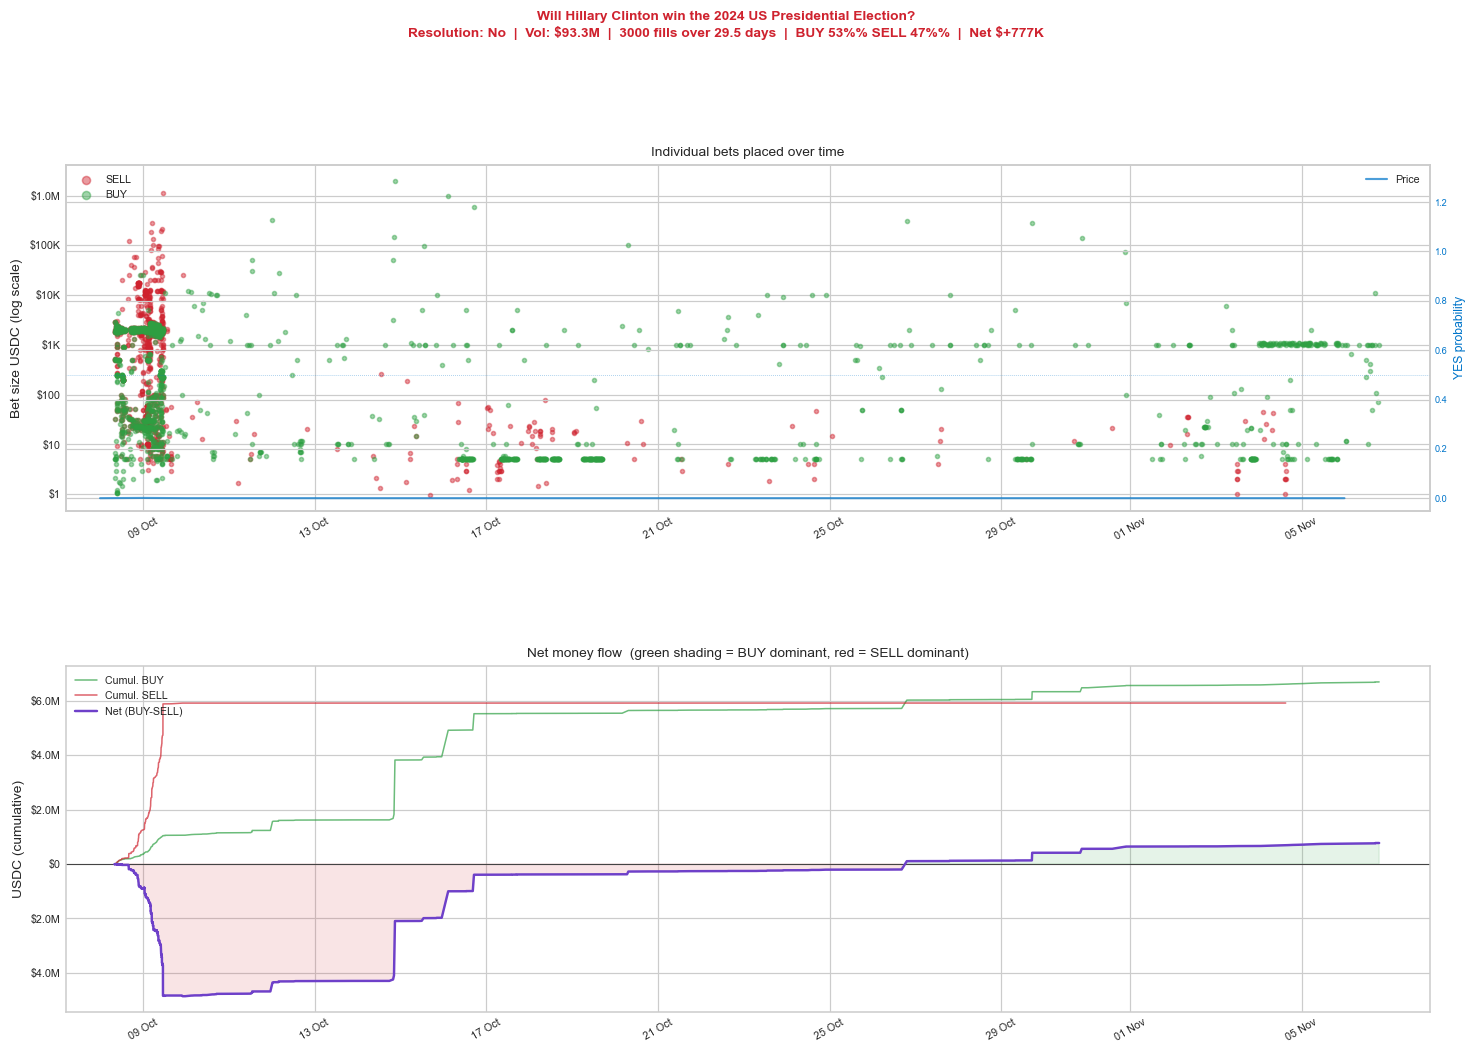


Fetching: Will Gavin Newsom be D-nom for VP on Election Day?


  3000 fills  span=36.7d  BUY=96%  net=$+85,004K


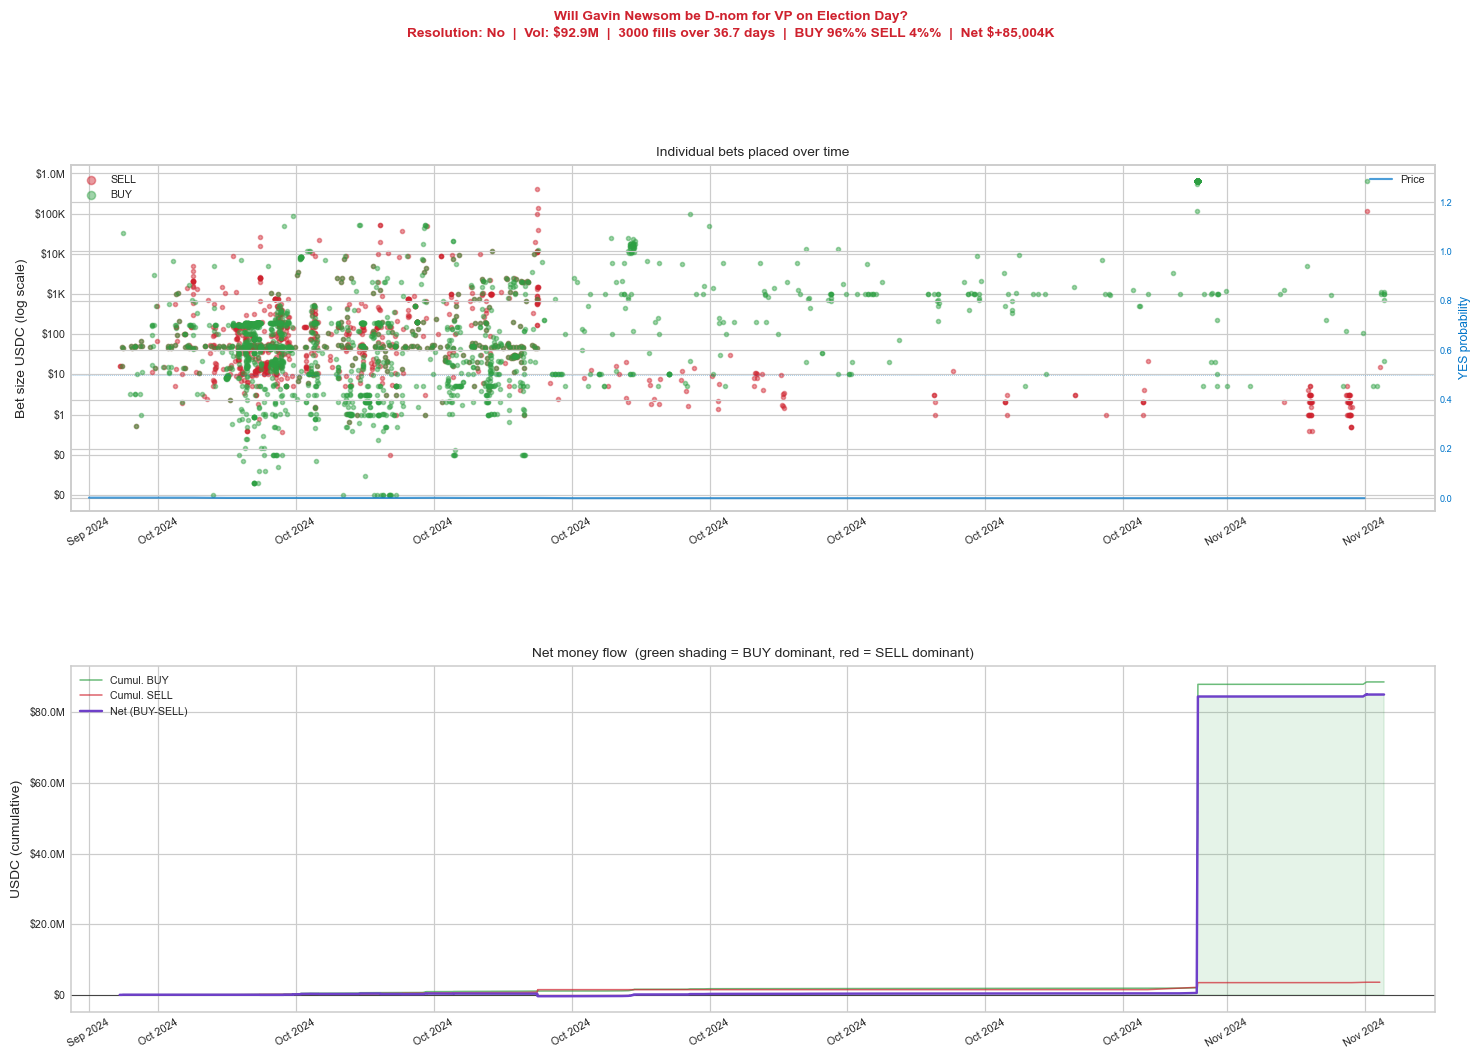


Fetching: Will Trump release the Epstein files by December 19?


  3000 fills  span=1.6d  BUY=74%  net=$+12,058K


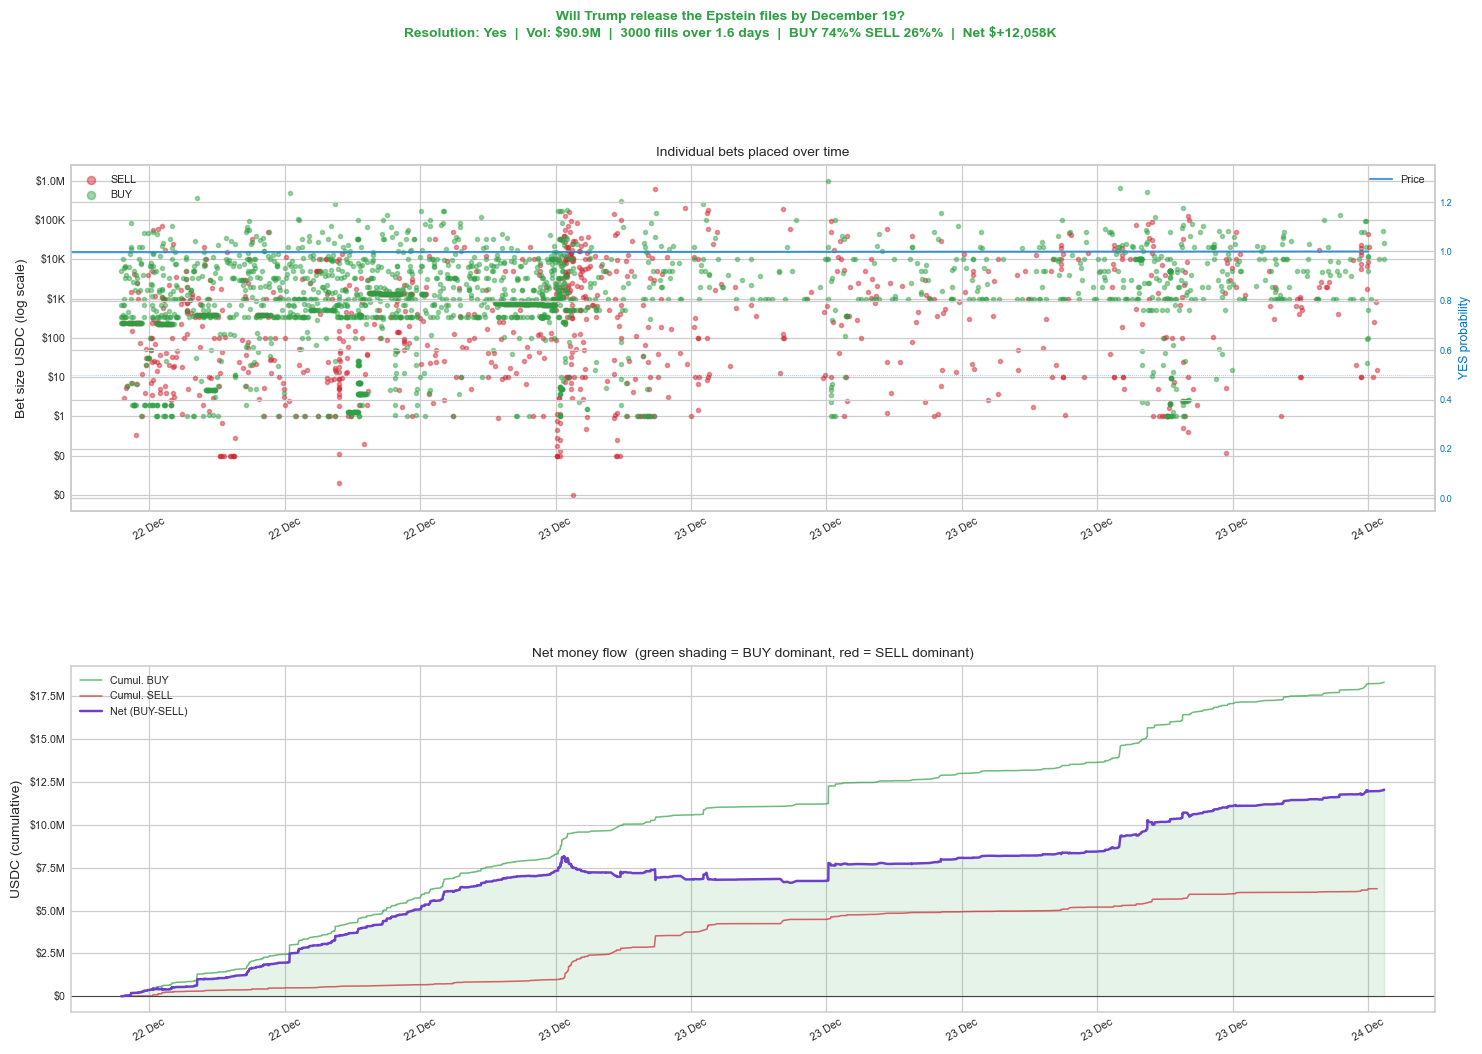


Fetching: Will Lee Jae-myung be elected the next president of South Korea?


  3000 fills  span=0.5d  BUY=37%  net=$-7,120K


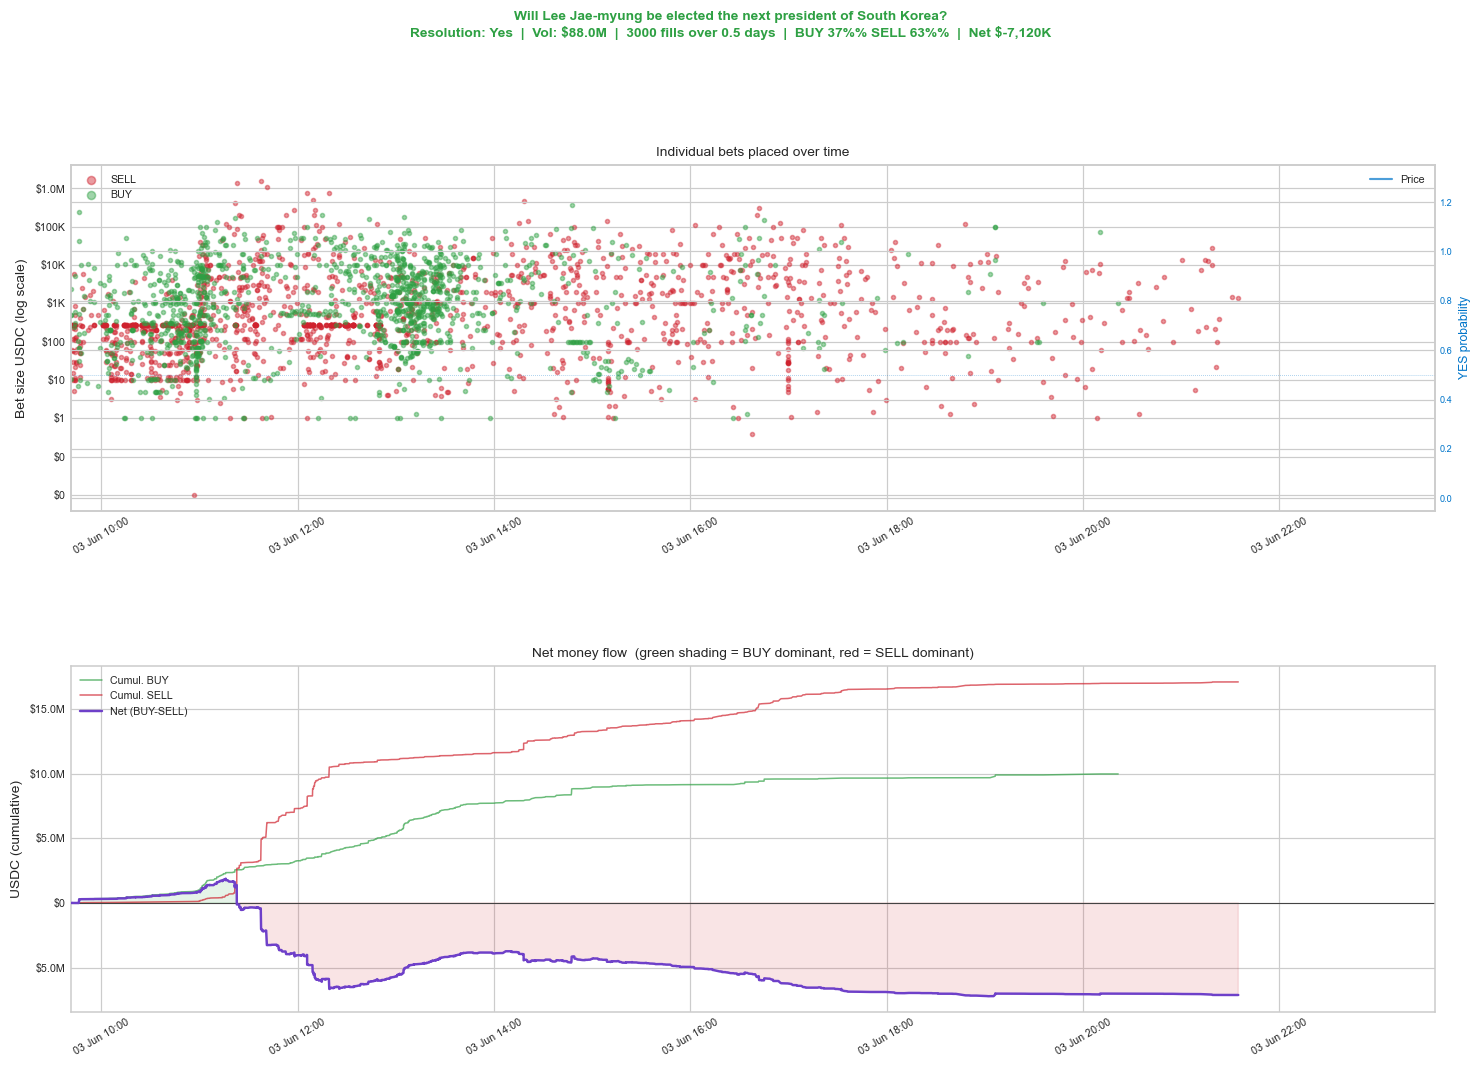


Fetching: Will Hunor Kelemen win the Romanian presidential election?


  3000 fills  span=87.1d  BUY=100%  net=$+80,420K


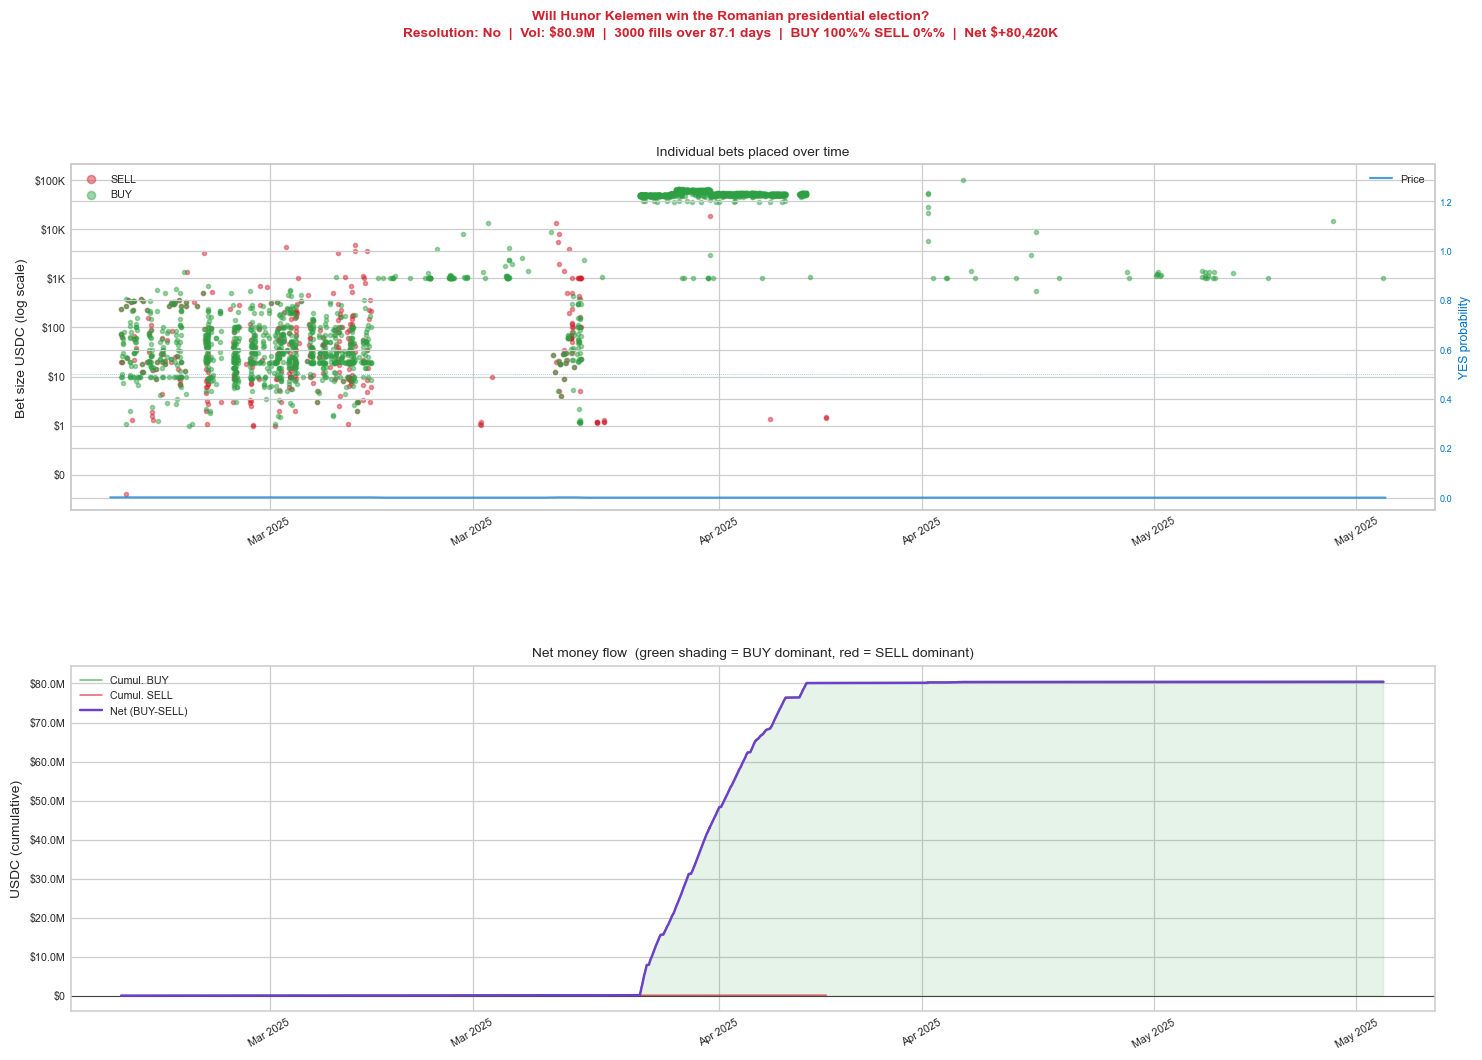


Fetching: Will Trump launch a coin before the election?


  3000 fills  span=0.5d  BUY=73%  net=$+13,105K


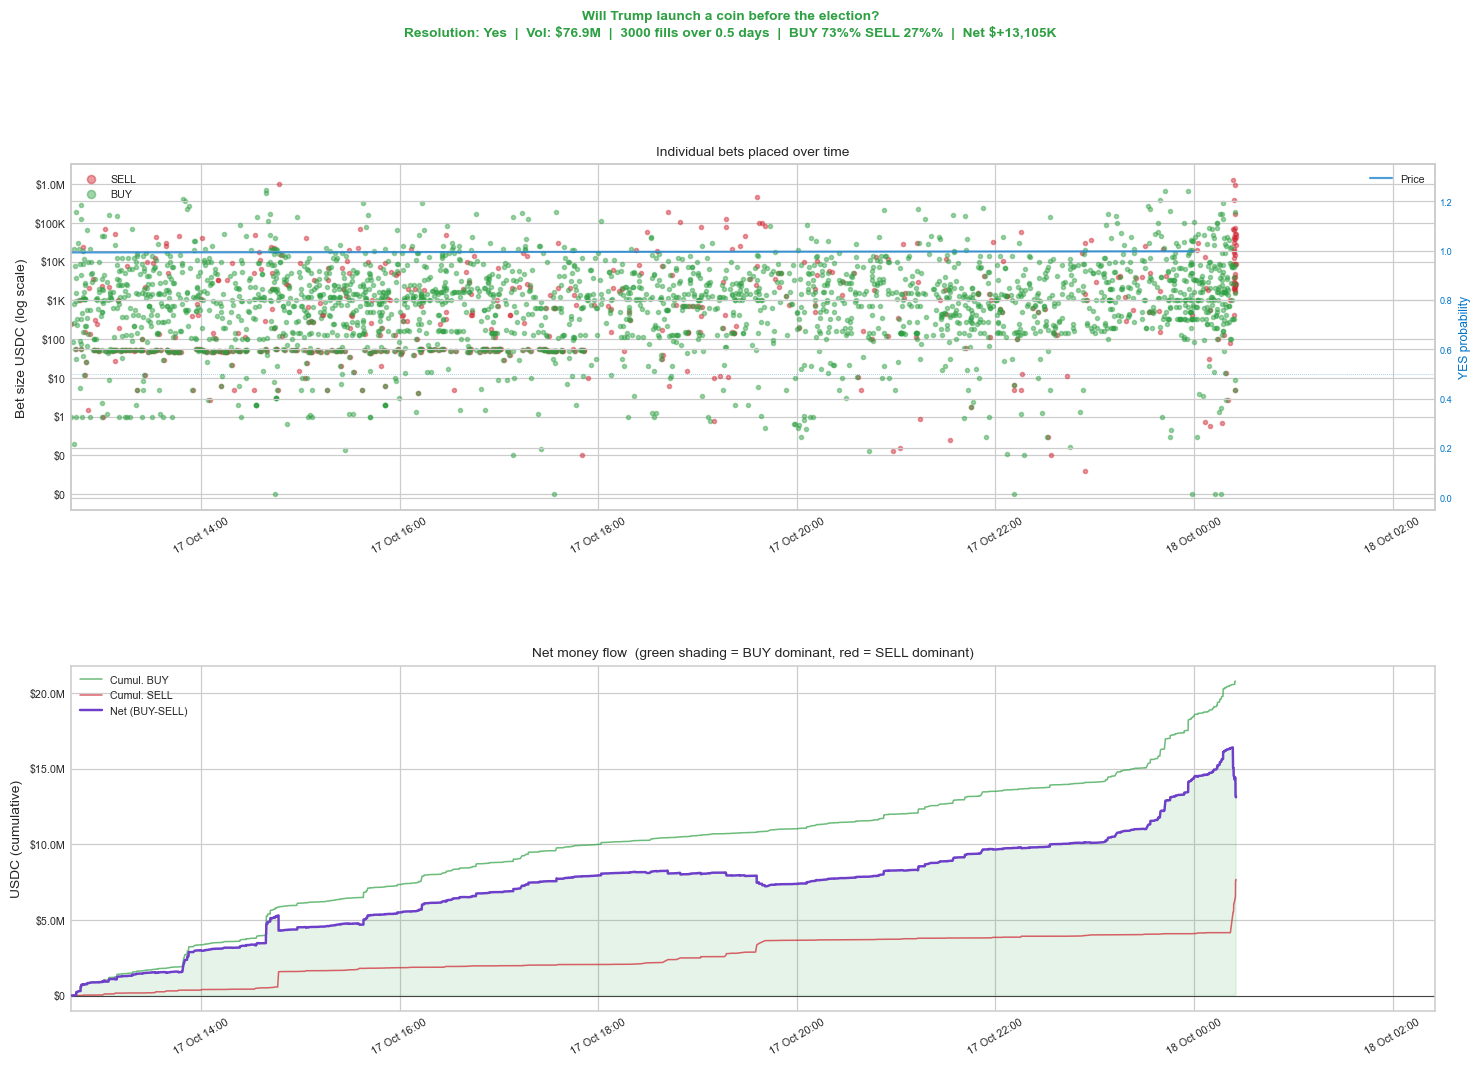


Fetching: Will Kim Moon-soo be elected the next president of South Korea?


  3000 fills  span=0.5d  BUY=57%  net=$+5,190K


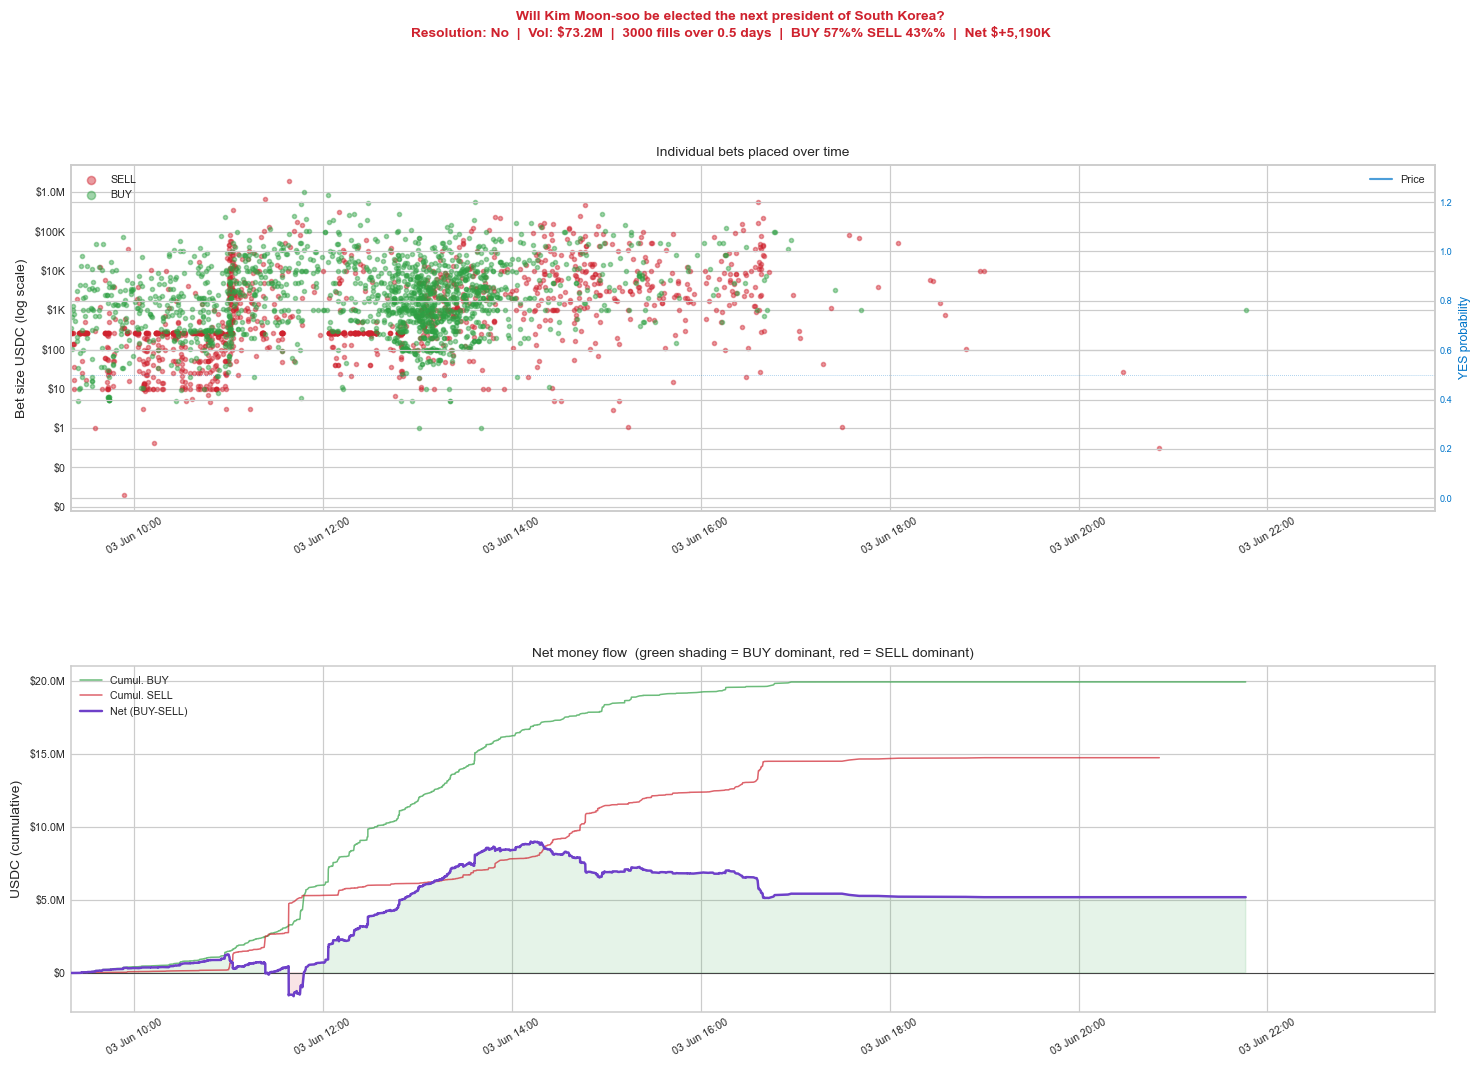


Fetching: Will Kamala Harris be inaugurated?


  3000 fills  span=2.0d  BUY=54%  net=$+151K


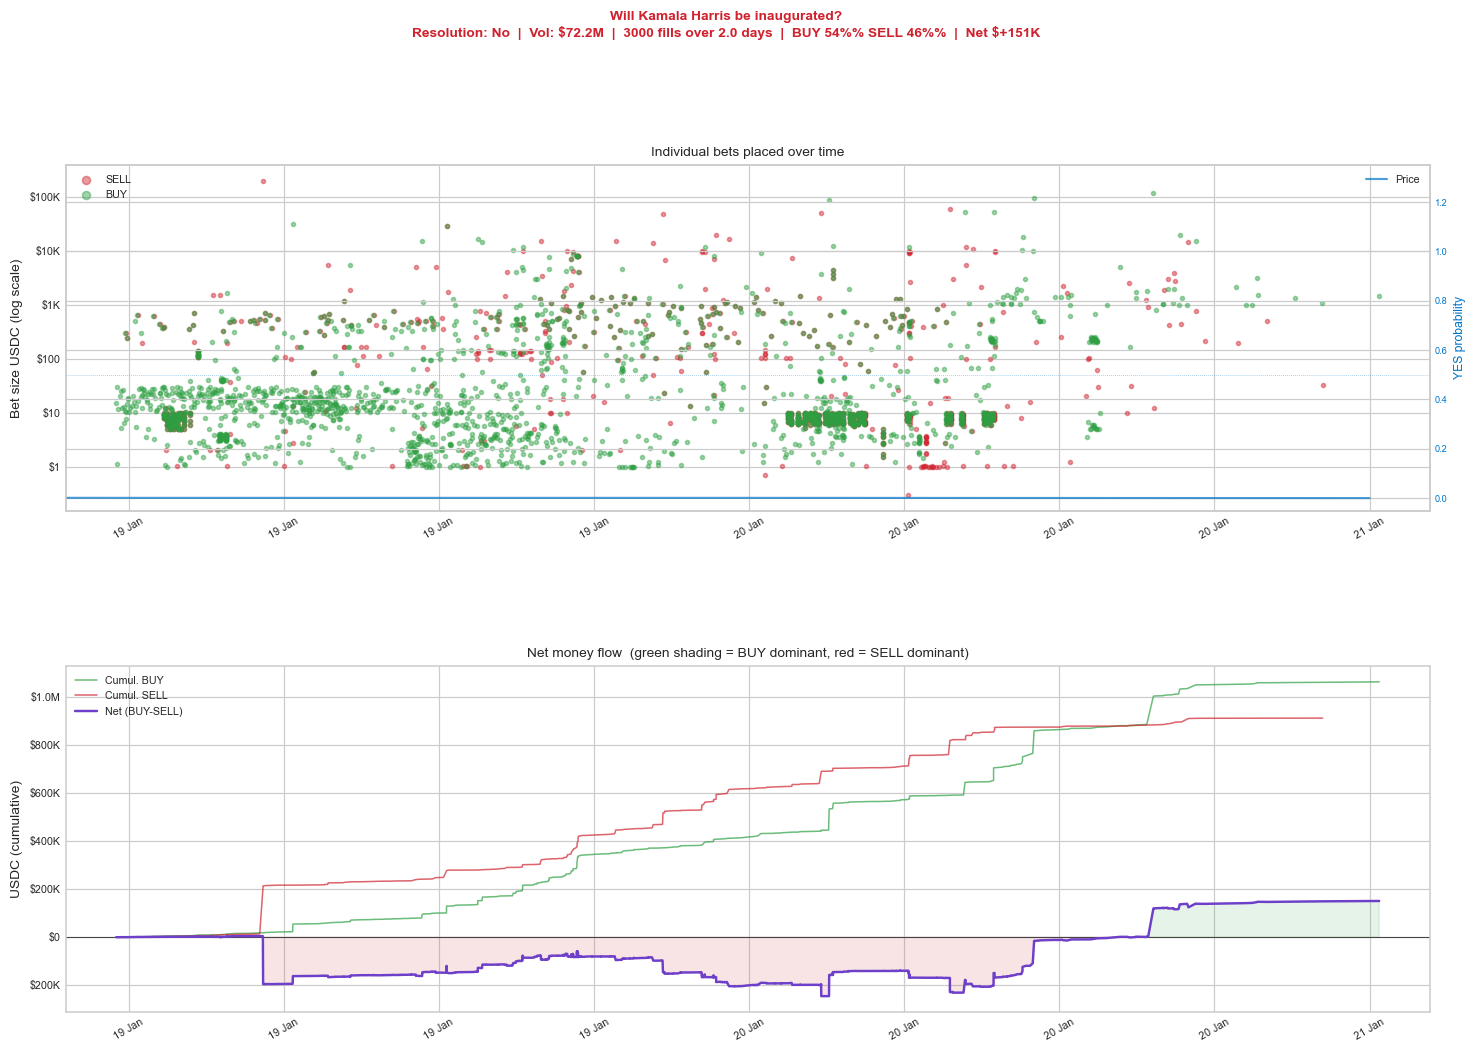

In [3]:
for row in markets.sort('volume_usdc', descending=True).iter_rows(named=True):
    slug       = row['slug']
    question   = row['question']
    resolution = row['resolution']
    total_vol  = float(row['volume_usdc'] or 0)
    cond_id    = row['condition_id']
    is_yes     = (resolution == 'Yes')
    c_res      = C_BUY if is_yes else C_SELL

    print(f'Fetching: {question[:65]}')

    ph = load_ph(slug)
    tr = fetch_all_trades(cond_id)

    if tr.is_empty():
        print('  No trade data — skipped')
        continue

    # Stats
    ts_min  = int(tr['timestamp'].min())
    ts_max  = int(tr['timestamp'].max())
    span_d  = (ts_max - ts_min) / 86400
    buys    = tr.filter(pl.col('side') == 'BUY')
    sells   = tr.filter(pl.col('side') == 'SELL')
    buy_v   = float(buys['size'].sum()  or 0)
    sell_v  = float(sells['size'].sum() or 0)
    net_v   = buy_v - sell_v
    buy_pct = 100 * buy_v / (buy_v + sell_v) if (buy_v + sell_v) > 0 else 0
    max_bet = float(tr['size'].max() or 0)
    print(f'  {len(tr)} fills  span={span_d:.1f}d  BUY={buy_pct:.0f}%  net=${net_v/1e3:+,.0f}K')

    # X-axis = trade window only
    from datetime import datetime, timedelta
    t0  = datetime.fromtimestamp(ts_min)
    t1  = datetime.fromtimestamp(ts_max)
    pad = timedelta(seconds=max((ts_max - ts_min) * 0.04, 3600))
    xlim = (t0 - pad, t1 + pad)

    # Clip price history to trade window (±1 day buffer for daily candles)
    ph_clip = ph.filter(
        (pl.col('timestamp') >= ts_min - 86400) &
        (pl.col('timestamp') <= ts_max + 86400)
    ) if not ph.is_empty() else ph

    date_fmt = mdates.DateFormatter('%d %b %H:%M' if span_d < 1
                                    else '%d %b' if span_d < 30 else '%b %Y')

    title_line = (
        f'{question}\n'
        f'Resolution: {resolution}  |  Vol: \${total_vol/1e6:.1f}M  |  '
        f'{len(tr)} fills over {span_d:.1f} days  |  '
        f'BUY {buy_pct:.0f}%% SELL {100-buy_pct:.0f}%%  |  '
        f'Net \${net_v/1e3:+,.0f}K'
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10),
                                    gridspec_kw={'hspace': 0.45})
    fig.suptitle(title_line, fontsize=9, fontweight='bold', color=c_res, y=1.02)

    # Panel 1 — individual bets
    for side, col, z in [('SELL', C_SELL, 2), ('BUY', C_BUY, 3)]:
        sub = tr.filter(pl.col('side') == side)
        if not sub.is_empty():
            ax1.scatter(sub['date'].to_list(), sub['size'].to_list(),
                        s=7, alpha=0.45, color=col, label=side, zorder=z)

    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(fmt_usdc)
    ax1.set_ylabel('Bet size USDC (log scale)')
    ax1.set_title('Individual bets placed over time', fontsize=9)
    ax1.legend(markerscale=2, loc='upper left')
    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_formatter(date_fmt)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

    # Price overlay clipped to trade window
    if not ph_clip.is_empty():
        ax1b = ax1.twinx()
        ax1b.plot(ph_clip['date'].to_list(), ph_clip['price'].to_list(),
                  color=C_PRICE, linewidth=1.4, alpha=0.7, label='Price')
        ax1b.set_ylim(-0.05, 1.35)
        ax1b.set_ylabel('YES probability', color=C_PRICE, fontsize=8)
        ax1b.tick_params(axis='y', colors=C_PRICE, labelsize=6)
        ax1b.axhline(0.5, color=C_PRICE, linewidth=0.5, linestyle=':', alpha=0.5)
        ax1b.legend(loc='upper right', fontsize=7)
        ax1b.set_xlim(*xlim)

    # Panel 2 — net money flow
    signed = pl.concat([
        buys.select(['date',  pl.col('size').alias('net')]),
        sells.select(['date', (-pl.col('size')).alias('net')]),
    ]).sort('date')

    dates_net = signed['date'].to_list()
    cum_net   = np.cumsum(signed['net'].cast(pl.Float64).to_list())

    if not buys.is_empty():
        cum_buy = np.cumsum(buys.sort('date')['size'].cast(pl.Float64).to_list())
        ax2.plot(buys.sort('date')['date'].to_list(), cum_buy,
                 color=C_BUY, linewidth=1.0, alpha=0.7, label='Cumul. BUY')
    if not sells.is_empty():
        cum_sell = np.cumsum(sells.sort('date')['size'].cast(pl.Float64).to_list())
        ax2.plot(sells.sort('date')['date'].to_list(), cum_sell,
                 color=C_SELL, linewidth=1.0, alpha=0.7, label='Cumul. SELL')

    ax2.plot(dates_net, cum_net, color=C_NET, linewidth=1.6, label='Net (BUY-SELL)', zorder=4)
    cum_arr = np.array(cum_net)
    ax2.fill_between(dates_net, cum_arr, 0, where=cum_arr >= 0, color=C_BUY,  alpha=0.12)
    ax2.fill_between(dates_net, cum_arr, 0, where=cum_arr <  0, color=C_SELL, alpha=0.12)
    ax2.axhline(0, color='#444', linewidth=0.7)
    ax2.set_xlim(*xlim)
    ax2.yaxis.set_major_formatter(fmt_usdc)
    ax2.set_ylabel('USDC (cumulative)')
    ax2.set_title('Net money flow  (green shading = BUY dominant, red = SELL dominant)', fontsize=9)
    ax2.legend(loc='upper left')
    ax2.xaxis.set_major_formatter(date_fmt)
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    print()
